半二次 iter =  49 , TV + Dat = 6576.119379
半二次最小化完成
GLM iter =  49 , TV + Dat = 17654.057379
GLM Gibbs采样完成


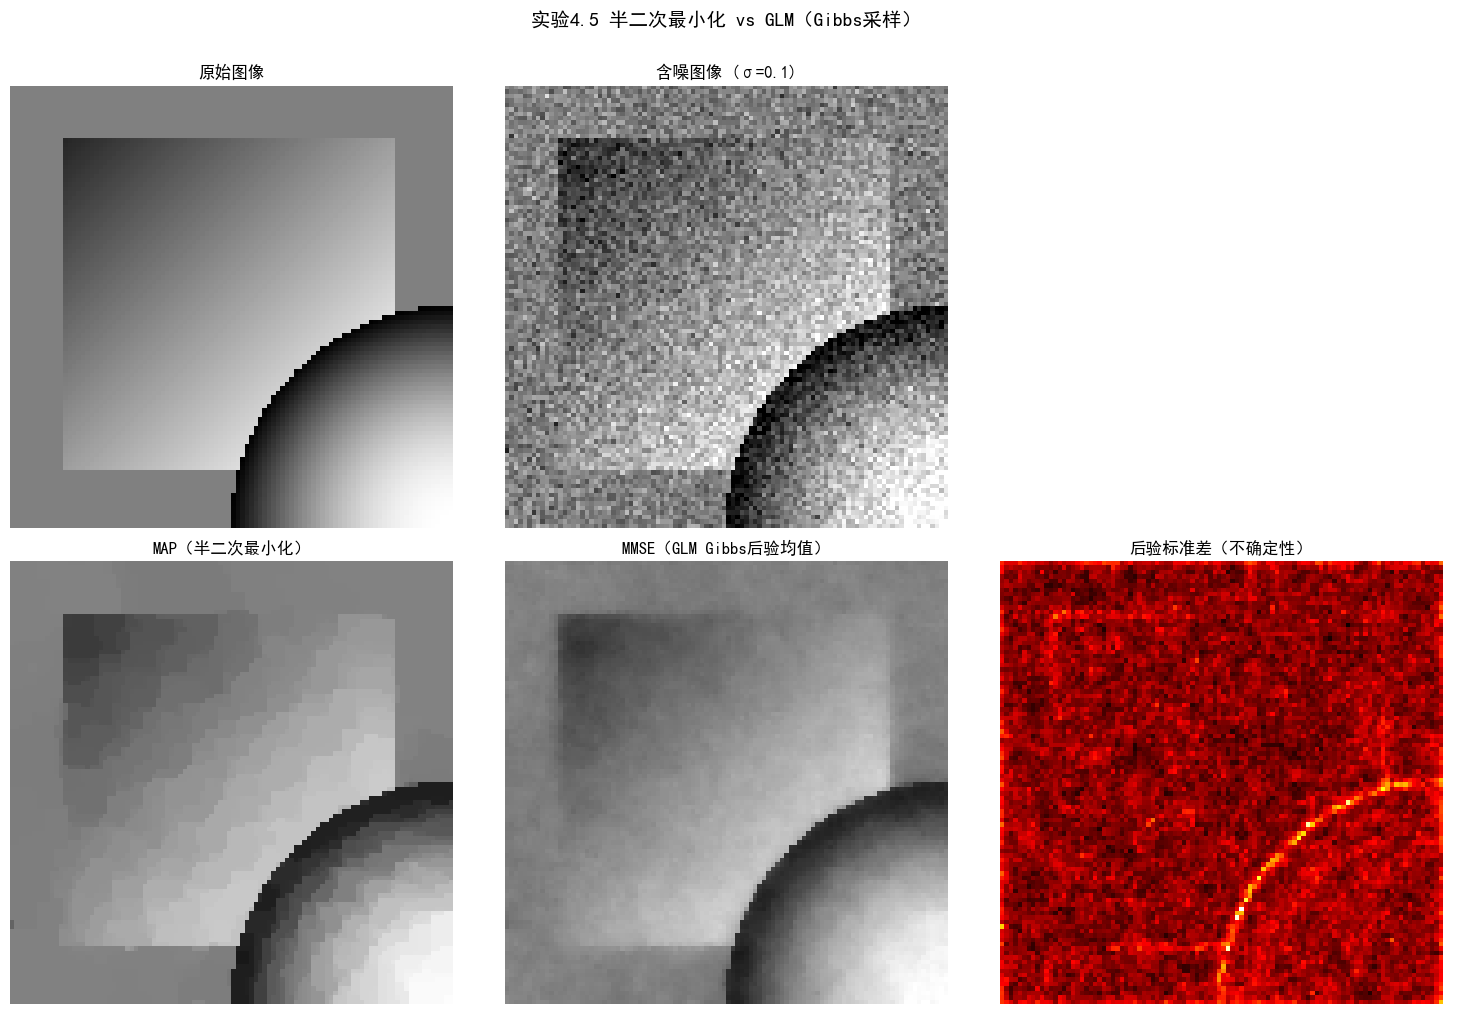

核心洞见：Gibbs采样 = 半二次最小化 + 噪声
  确定版：z = clip(|∇u|, eps)  vs  Gibbs版：z ~ GIG(0.5, λ|∇u|)
  确定版：CG精确右端  vs  Gibbs版：CG求解带高斯扰动的右端


In [2]:
"""
实验4.5 半二次最小化 vs GLM（Gibbs采样）：MAP vs MMSE
对应章节：4.5（Gibbs采样、半二次最小化→GLM、GIG分布、Gibbs=带噪声的交替最小化）
素材来源：Mathematics.../Teaching Unit 3/Labs/Lab_2.zip -> opt_vs_sample.ipynb
  - Cell 2: CG() 函数
  - Cell 3: Du() 函数
  - Cell 4: DTp() 函数
  - Cell 5: 合成图像生成代码
  - Cell 6: 加噪声代码
  - Cell 9: 半二次最小化 MAP
  - Cell 10: GLM Gibbs MMSE（含GIG采样，使用scipy.stats.geninvgauss）
"""

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.stats import geninvgauss
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# CG求解器（逐字取自 opt_vs_sample.ipynb Cell 2）
# ============================================================
def CG(x, Ax, sigma, lamb, z, b, maxit=100, verbose=0):
    r = b - Ax(sigma, lamb, z, x)
    p = r
    rsold = torch.sum(r**2)
    for it in range(maxit):
        Ap = Ax(sigma, lamb, z, p)
        alpha = rsold/torch.sum(p*Ap)
        x = x + alpha*p
        r = r - alpha*Ap
        rsnew = torch.sum(r**2)
        rsold = rsnew.clone()
        p = r + rsnew/rsold*p
        
        R = torch.mean(r**2)
        if R < 1e-9:
            break
    if verbose > 0:      
        print("CG: it = ", it, ", mse = ", R)
        
    return x

# ============================================================
# Du / DTp（逐字取自 opt_vs_sample.ipynb Cell 3/4）
# ============================================================
def Du(u):
    M, N = u.shape
    Du_out = torch.zeros((2, M, N))
    Du_out[0, :, :-1] += u[:, 1:] - u[:, :-1]
    Du_out[1, :-1, :] += u[1:, :] - u[:-1, :]
    return Du_out

def DTp(p):
    C, M, N = p.shape
    DTp_out = torch.zeros((M, N))
    DTp_out[:, 1:] += p[0, :, :-1]
    DTp_out[:, :-1] -= p[0, :, :-1]
    DTp_out[1:, :] += p[1, :-1, :]
    DTp_out[:-1, :] -= p[1, :-1, :]
    return DTp_out

# ============================================================
# 合成图像（逐字取自 opt_vs_sample.ipynb Cell 5）
# ============================================================
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)

X, Y = np.meshgrid(x, y)

u1 = 0*X+0.5
u2 = X+Y
u2 -= u2.min()
u2 /= u2.max()

u3 = np.clip(1-((1-X)**2+(1-Y)**2), a_min=0, a_max=None)
u3 -= u3.min()
u3 /= u3.max()

m1 = 0*X
m1[N//8:-N//8, N//8:-N//8]=1
u = u1
u[m1==1] = u2[m1==1]*1.25

m2 = 0*X
m2[(X-1)**2+(Y-1)**2 <= 1] = 1
u[m2==1] = u3[m2==1]

# ============================================================
# 加噪声（逐字取自 opt_vs_sample.ipynb Cell 6）
# ============================================================
sigma = 0.1
f = u + np.random.randn(N, N)*sigma

# 转为torch tensor（在半二次和GLM之前，确保 f_ 可用）
f_ = torch.from_numpy(f)

# ============================================================
# MAP：半二次最小化（逐字取自 opt_vs_sample.ipynb Cell 9）
# 交替更新：z = clip(|Du|, eps)，然后用CG求解u
# ============================================================
maxiter = 50
lamb = 10.0

Au = lambda sigma, lamb, z, u: lamb*DTp(Du(u)/z) + u/sigma**2
rhs = f_/sigma**2

u_ = torch.from_numpy(f)

for it in range(maxiter):
    diff_u = torch.abs(Du(u_))
    
    z_ = np.clip(diff_u, a_min=1e-6, a_max=None)
    u_ = CG(u_, Au, sigma, lamb, z_, rhs, maxit=1000, verbose=0)
    
    TV = lamb*diff_u.sum()
    Dat = torch.sum((u_-f_)**2/(2*sigma**2))

    print("半二次 iter = ", it,
          ", TV + Dat =", "{:3.6f}".format(TV + Dat),
          end="\r")

u_hq = u_  # 保存半二次结果
print("\n半二次最小化完成")


# ============================================================
# MMSE：GLM Gibbs采样（逐字取自 opt_vs_sample.ipynb Cell 10）
# 交替采样：z ~ GIG(0.5, λ|Du|)，然后从条件高斯采样u（CG+扰动）
# ============================================================
maxiter = 50
lamb = 20

u_ = torch.from_numpy(f)

Au = lambda sigma, lamb, z, u: DTp(Du(u)/z) + u/sigma**2

u_sum_ = 0
u_sqr_ = 0

for it in range(maxiter):
    
    diff_u = torch.abs(Du(u_))
    tmp = diff_u.numpy().ravel()
    tmp[tmp == 0] = 1e-30
    
    z_ = torch.from_numpy(geninvgauss.rvs(0.5, lamb*tmp)*tmp/lamb).reshape(2,N,N)
    eta = torch.normal(0,1,size=(3,N,N))
    
    rhs = DTp(eta[:2]/torch.sqrt(z_))+ eta[2]/sigma + f_/sigma**2
    u_ = CG(u_, Au, sigma, lamb, z_, rhs, maxit=1000, verbose=0)
   
    u_sum_ += u_
    u_sqr_ += u_**2
    
    TV = lamb*diff_u.sum()
    Dat = torch.sum((u_-f_)**2/(2*sigma**2))
    
    print("GLM iter = ", it,
          ", TV + Dat =", "{:3.6f}".format(TV + Dat),
          end="\r")

print("\nGLM Gibbs采样完成")

u_avg_ = u_sum_/maxiter
u_var_ = u_sqr_/maxiter - u_avg_**2


# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0][0].imshow(u, cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('原始图像')
axes[0][0].axis('off')

axes[0][1].imshow(f, cmap='gray', vmin=0, vmax=1)
axes[0][1].set_title(f'含噪图像 (σ={sigma})')
axes[0][1].axis('off')

axes[0][2].axis('off')

axes[1][0].imshow(u_hq.reshape(N, N), cmap='gray', vmin=0, vmax=1)
axes[1][0].set_title('MAP（半二次最小化）')
axes[1][0].axis('off')

axes[1][1].imshow(u_avg_.reshape(N, N), cmap='gray', vmin=0, vmax=1)
axes[1][1].set_title('MMSE（GLM Gibbs后验均值）')
axes[1][1].axis('off')

axes[1][2].imshow(torch.sqrt(u_var_), cmap='hot')
axes[1][2].set_title('后验标准差（不确定性）')
axes[1][2].axis('off')

fig.suptitle('实验4.5 半二次最小化 vs GLM（Gibbs采样）', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('实验4_5_半二次vs_GLM.png', dpi=150, bbox_inches='tight')
plt.show()

print("核心洞见：Gibbs采样 = 半二次最小化 + 噪声")
print("  确定版：z = clip(|∇u|, eps)  vs  Gibbs版：z ~ GIG(0.5, λ|∇u|)")
print("  确定版：CG精确右端  vs  Gibbs版：CG求解带高斯扰动的右端")
